In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data generated by your collector
df = pd.read_csv('../data/raw/aarhus_air_quality_raw.csv')

# Convert the timestamp string back to a proper datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display the first few rows
display(df.head())
display(df.info())

,timestamp,pm2_5,no2
0,2026-03-09 00:00:00,27.5,23.6
1,2026-03-09 01:00:00,27.3,19.1
2,2026-03-09 02:00:00,26.7,18.1
3,2026-03-09 03:00:00,26.3,16.9
4,2026-03-09 04:00:00,25.4,16.1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  840 non-null    datetime64[ns]
 1   pm2_5      840 non-null    float64       
 2   no2        840 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 19.8 KB


None

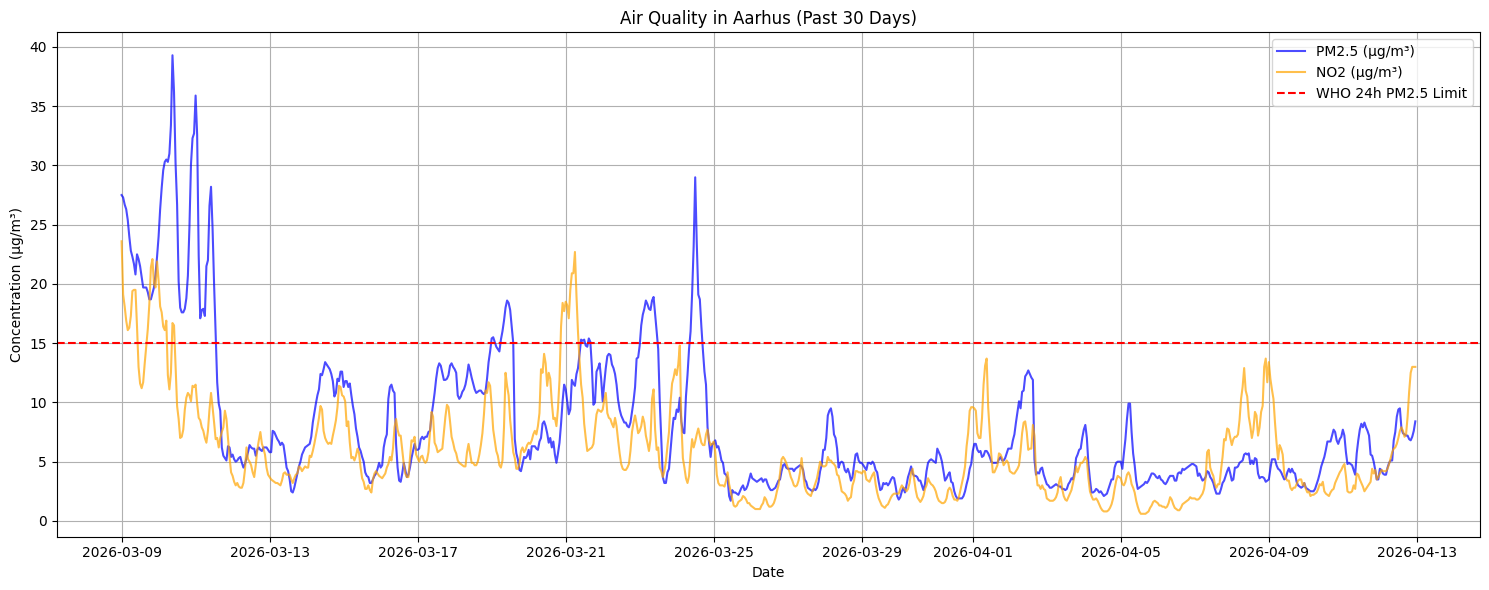

In [3]:
# Set the timestamp as the index for easier plotting
df_time = df.set_index('timestamp')

# Plot PM2.5 and NO2 over the last 30 days
plt.figure(figsize=(15, 6))
plt.plot(df_time.index, df_time['pm2_5'], label='PM2.5 (µg/m³)', color='blue', alpha=0.7)
plt.plot(df_time.index, df_time['no2'], label='NO2 (µg/m³)', color='orange', alpha=0.7)

# Add horizontal line for WHO PM2.5 Safety Guideline (approx 15 µg/m³ for 24h)
plt.axhline(y=15, color='red', linestyle='--', label='WHO 24h PM2.5 Limit')

plt.title('Air Quality in Aarhus (Past 30 Days)')
plt.xlabel('Date')
plt.ylabel('Concentration (µg/m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

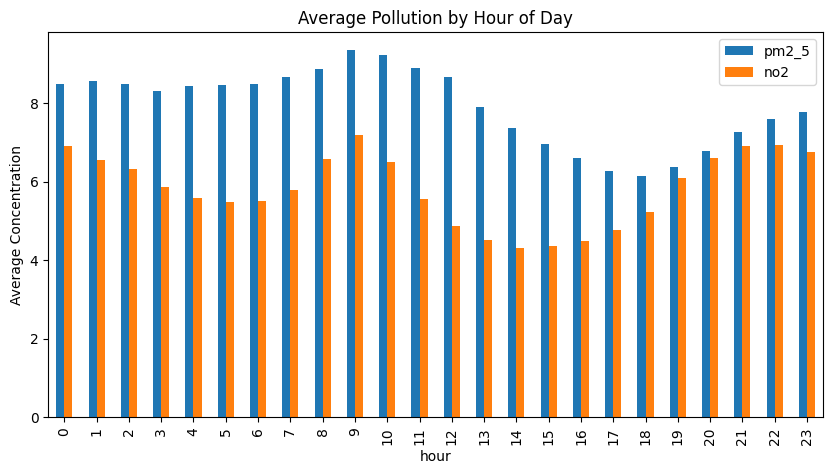

In [4]:
# Cell 3: Checking for Daily Patterns
df['hour'] = df['timestamp'].dt.hour
hourly_avg = df.groupby('hour')[['pm2_5', 'no2']].mean()

hourly_avg.plot(kind='bar', figsize=(10, 5), title='Average Pollution by Hour of Day')
plt.ylabel('Average Concentration')
plt.show()